In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
from dataclasses import dataclass
from typing import Tuple, List, Callable

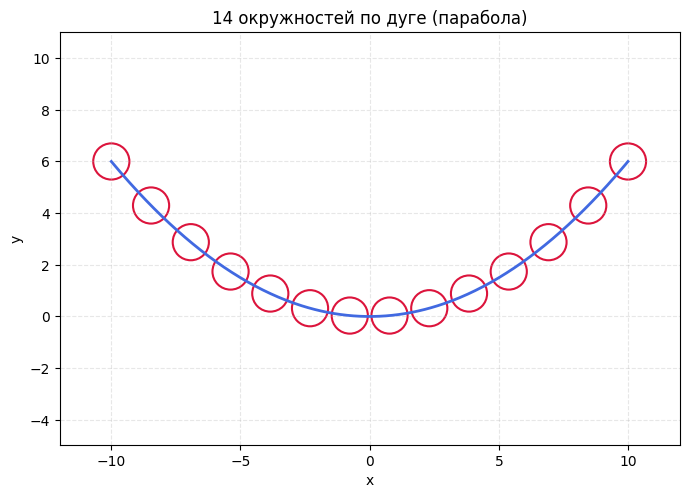

In [2]:
# Параметры параболы: y = a*x^2 + b*x + c
a, b, c = 0.06, 0.0, 0.0

# Диапазон x для дуги (напр., от -10 до 10)
x_start, x_end = -10, 10

# Количество окружностей
n = 14

# Радиусы окружностей (фиксированный или зависимый от кривизны)
r_const = .7
# Генерируем точки на дуге (равномерно по x)
xs = np.linspace(x_start, x_end, n)
ys = a*xs**2 + b*xs + c

# Настройка холста
fig, ax = plt.subplots(figsize=(8, 6))
ax.set_aspect('equal', adjustable='box')
ax.grid(True, linestyle='--', alpha=0.3)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('14 окружностей по дуге (парабола)')

# Рисуем саму дугу для наглядности
x_curve = np.linspace(x_start, x_end, 400)
y_curve = a*x_curve**2 + b*x_curve + c
ax.plot(x_curve, y_curve, color='royalblue', lw=2)

# Добавляем окружности по точкам дуги
for x, y in zip(xs, ys):
    circle = Circle((x, y), radius=r_const, edgecolor='crimson', facecolor='none', lw=1.5)
    ax.add_patch(circle)

# Границы окна
pad = 2
ax.set_xlim(x_start - pad, x_end + pad)
ax.set_ylim(min(ys) - 5, max(ys) + 5)

plt.show()

Среднее расстояние между центрами: 1.3992 (ожидание 1.4000)
Расстояние между центрами: [1.39987326 1.3998249  1.39975429 1.39965087 1.39950238 1.3992995
 1.39905019 1.39879891 1.39863039 1.39862313 1.39878091 1.39902894
 1.39928076]


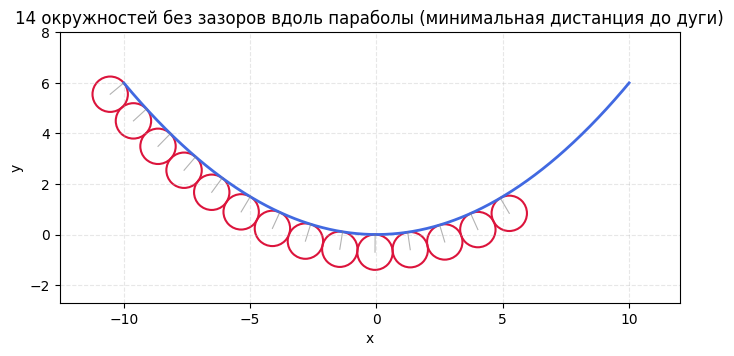

In [3]:
# ===== Geometry primitives =====

@dataclass(frozen=True)
class Parabola:
    """y = a*x^2 + b*x + c"""
    a: float
    b: float
    c: float

    def point(self, x: float) -> np.ndarray:
        return np.array([x, self.a * x**2 + self.b * x + self.c], dtype=float)

    def dy_dx(self, x: float) -> float:
        return 2 * self.a * x + self.b

    def tangent(self, x: float) -> np.ndarray:
        t = np.array([1.0, self.dy_dx(x)], dtype=float)
        return t / np.linalg.norm(t)

    def normal(self, x: float) -> np.ndarray:
        # Rotate tangent by -90°: (tx, ty) -> (ty, -tx)
        t = self.tangent(x)
        n = np.array([t[1], -t[0]], dtype=float)
        return n / np.linalg.norm(n)


class OffsetCurve:
    """Смещённая кривая на расстояние r вдоль нормали исходной кривой."""
    def __init__(self, base_curve: Parabola, r: float):
        self.base = base_curve
        self.r = float(r)

    def center_at_x(self, x: float) -> np.ndarray:
        p = self.base.point(x)
        n = self.base.normal(x)
        return p + self.r * n

    def base_point_and_center(self, x: float) -> Tuple[np.ndarray, np.ndarray]:
        p = self.base.point(x)
        c = self.center_at_x(x)
        return p, c


# ===== Arc-length utilities =====

class ArcLengthParameterizer:
    """
    Вычисляет параметризацию по длине для функции R(x): R: x -> 2D,
    затем даёт точки с равными шагами по длине.
    """
    def __init__(self, func: Callable[[np.ndarray], np.ndarray], x_min: float, x_max: float, samples: int = 5000):
        self.func = func
        self.x_min = float(x_min)
        self.x_max = float(x_max)
        self.samples = int(samples)

        self._xdense = np.linspace(self.x_min, self.x_max, self.samples)
        self._rdense = self.func(self._xdense)  # shape: (N, 2)
        diffs = np.diff(self._rdense, axis=0)
        seglen = np.linalg.norm(diffs, axis=1)
        s = np.cumsum(seglen)
        self._s = np.concatenate([[0.0], s])  # длина от начала

    def total_length(self) -> float:
        return float(self._s[-1])

    def points_by_step(self, step: float, count: int) -> Tuple[np.ndarray, np.ndarray]:
        """
        Возвращает x-параметры и точки R(x) с равным шагом 'step' по длине.
        Если суммарной длины не хватает, шаг масштабируется, чтобы вместить count точек.
        """
        total = self.total_length()
        if step * (count - 1) > total:
            step = total / max(count - 1, 1)

        targets = np.linspace(0.0, step * (count - 1), count)
        x = np.interp(targets, self._s, self._xdense)
        pts = self.func(x)
        return x, pts


# ===== Packing strategy =====

class CirclePacker:
    """
    Размещает n окружностей радиуса r вдоль параболы без зазоров:
    - центры лежат на смещённой кривой (offset) на расстоянии r (минимальная дистанция до параболы)
    - шаг по дуге центров равен 2r (касание соседей)
    """
    def __init__(self, parabola: Parabola, r: float, x_min: float, x_max: float):
        self.parabola = parabola
        self.r = float(r)
        self.x_min = float(x_min)
        self.x_max = float(x_max)

        self.offset = OffsetCurve(self.parabola, self.r)
        # параметризуем центры вдоль offset-кривой
        self.param = ArcLengthParameterizer(
            func=lambda xs: np.stack([self.offset.center_at_x(x) for x in xs]),
            x_min=self.x_min,
            x_max=self.x_max,
            samples=6000
        )

    def pack(self, n: int) -> Tuple[np.ndarray, np.ndarray, List[float]]:
        """
        Возвращает:
        - centers: (n, 2) координаты центров
        - bases:   (n, 2) точки на базовой параболе под центрами
        - xs: список x-параметров базовой кривой
        """
        # шаг по длине для касания соседних окружностей:
        step = 2.0 * self.r

        xs, centers = self.param.points_by_step(step=step, count=n)
        bases = np.stack([self.parabola.point(x) for x in xs])
        return centers, bases, list(xs)
    
    @staticmethod
    def calc_distances(centers: np.ndarray) -> np.ndarray:
        """Вычисляет расстояния между соседними центрами окружностей."""
        diffs = np.diff(centers, axis=0)
        dists = np.linalg.norm(diffs, axis=1)
        return dists


# ===== Visualization =====

@dataclass(frozen=True)
class PlotStyle:
    curve_color: str = "royalblue"
    curve_lw: float = 2.0
    circle_edge: str = "crimson"
    circle_face: str = "none"
    circle_lw: float = 1.5
    grid_alpha: float = 0.3


class Scene:
    def __init__(self, style: PlotStyle = PlotStyle()):
        self.style = style
    
    def draw(self,
             parabola: Parabola,
             centers: np.ndarray,
             bases: np.ndarray,
             r: float,
             x_min: float,
             x_max: float,
             title: str = "Окружности без зазоров вдоль параболы"):
        fig, ax = plt.subplots(figsize=(8, 6))
        ax.set_aspect('equal', adjustable='box')
        ax.grid(True, linestyle='--', alpha=self.style.grid_alpha)
        ax.set_xlabel('x')
        ax.set_ylabel('y')
        ax.set_title(title)

        # Базовая кривая
        x_curve = np.linspace(x_min, x_max, 800)
        y_curve = parabola.a * x_curve**2 + parabola.b * x_curve + parabola.c
        ax.plot(x_curve, y_curve, color=self.style.curve_color, lw=self.style.curve_lw)

        # Окружности
        for (cx, cy) in centers:
            ax.add_patch(Circle((cx, cy), radius=r,
                                edgecolor=self.style.circle_edge,
                                facecolor=self.style.circle_face,
                                lw=self.style.circle_lw))
        
        # Визуализация коротких нормалей (центр -> базовая точка) для проверки минимальной дистанции
        for (c, b) in zip(centers, bases):
            ax.plot([b[0], c[0]], [b[1], c[1]], color="gray", lw=0.8, alpha=0.6)

        # Границы
        all_x = np.concatenate([x_curve, centers[:, 0], bases[:, 0]])
        all_y = np.concatenate([y_curve, centers[:, 1], bases[:, 1]])
        pad = 2.0
        ax.set_xlim(np.min(all_x) - pad, np.max(all_x) + pad)
        ax.set_ylim(np.min(all_y) - pad, np.max(all_y) + pad)

        plt.show()


# ===== Application (composition) =====

def main():
    # Параметры из вашего примера
    a, b, c = 0.06, 0.0, 0.0
    x_start, x_end = -10.0, 10.0
    n = 14
    r_const = 0.7

    parabola = Parabola(a=a, b=b, c=c)
    packer = CirclePacker(parabola=parabola, r=r_const, x_min=x_start, x_max=x_end)

    centers, bases, xs = packer.pack(n=n)

    # Проверка касания соседей (расстояние центров ~ 2r)
    dists = np.linalg.norm(np.diff(centers, axis=0), axis=1)
    print(f"Среднее расстояние между центрами: {np.mean(dists):.4f} (ожидание {2*r_const:.4f})")

    calc_dists = CirclePacker.calc_distances(centers)
    print(f"Расстояние между центрами: {calc_dists}")

    scene = Scene()
    scene.draw(parabola=parabola,
               centers=centers,
               bases=bases,
               r=r_const,
               x_min=x_start,
               x_max=x_end,
               title="14 окружностей без зазоров вдоль параболы (минимальная дистанция до дуги)")

if __name__ == "__main__":
    main()


градиентный спуск

stops iterating on step 136
Расстояния между центрами:
 [2.19321188 2.19175735 2.18689651 2.17993522 2.17513183 2.17282903
 2.17180823 2.17224354 2.175067   2.1807992  2.18716198 2.19140811
 2.19218865] 
диаметр = 2.2


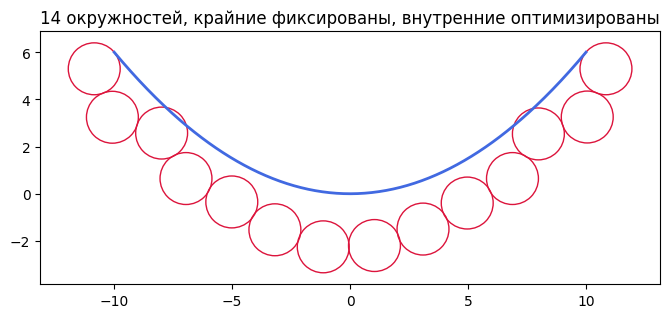

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle

# Парабола
def parabola(x, a=0.06, b=0.0, c=0.0):
    return a*x**2 + b*x + c

def tangent(x, a=0.06, b=0.0):
    dy = 2*a*x + b
    t = np.array([1.0, dy])
    return t / np.linalg.norm(t)

def normal(x, a=0.06, b=0.0):
    t = tangent(x, a, b)
    n = np.array([t[1], -t[0]])
    return n / np.linalg.norm(n)

def offset_point(x, r, a=0.06, b=0.0, c=0.0):
    p = np.array([x, parabola(x,a,b,c)])
    return p + r*normal(x,a,b)

def visualize():
    # Визуализация
    fig, ax = plt.subplots(figsize=(8,6))
    ax.set_aspect('equal')
    x_curve = np.linspace(x_start, x_end, 400)
    ax.plot(x_curve, parabola(x_curve), 'royalblue', lw=2)
    for c in centers:
        ax.add_patch(Circle(c, r, edgecolor='crimson', facecolor='none'))
    ax.set_title("14 окружностей, крайние фиксированы, внутренние оптимизированы")
    # input("press any to continue")

# Параметры
n = 14
r = 1.1
x_start, x_end = -10, 10

# Фиксируем крайние точки
left = offset_point(x_start, r)
right = offset_point(x_end, r)

# Инициализация внутренних центров равномерно
xs = np.linspace(x_start, x_end, n)
centers = np.array([offset_point(x, r) for x in xs])

# # Функция стоимости
def cost(centers):
    d = np.linalg.norm(np.diff(centers, axis=0), axis=1)
    return np.sum((d - 2*r)**2)

# Итеративная коррекция (градиентный спуск)   
def dist_resolve(centers: np.ndarray, _range= 50000, r=1.1) -> np.ndarray:
    accuracy = 0.005
    lr = 0.25
    for step in range(_range):
        for i in range(1, n-1):  # внутренние точки
            left_dist = np.linalg.norm(centers[i] - centers[i-1])
            right_dist = np.linalg.norm(centers[i] - centers[i+1])
            
            grad = (left_dist - 2*r) * (centers[i] - centers[i-1]) / (left_dist+1e-6) \
                + (right_dist - 2*r) * (centers[i] - centers[i+1]) / (right_dist+1e-6)
            
            centers[i] -= lr * grad
        _cost = cost(centers)
        # _diffs = abs(np.linalg.norm(np.diff(centers, axis=0), axis=1) - 2*r)

        # visualize()
        
        if cost(centers) < accuracy:
            print(f"stops iterating on step {step}")
            break
        # lr = lr*0.95
        # if _diffs.max() < accuracy: 
        #     print(f"stops iterating on step {step}")
        #     break

# разрешение промежутков и коллизий
dist_resolve(centers, r=r)

# Проверка расстояний
dists = np.linalg.norm(np.diff(centers, axis=0), axis=1)
print("Расстояния между центрами:\n", dists, "\nдиаметр =", 2*r)
visualize()

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle

# Параметры
n = 14
r = 1.1
x_start, x_end = -10, 10

# Инициализация внутренних центров равномерно
xs = np.linspace(x_start, x_end, n)
centers = np.array([offset_point(x, r) for x in xs])

# ====== вспомогательные ======
def parabola(x, a=0.06, b=0.0, c=0.0):
    return a*x**2 + b*x + c

def tangent(x, a=0.06, b=0.0):
    dy = 2*a*x + b
    t = np.array([1.0, dy])
    return t / np.linalg.norm(t)

def normal(x, a=0.06, b=0.0):
    t = tangent(x, a, b)
    n = np.array([t[1], -t[0]])
    return n / np.linalg.norm(n)

def offset_point(x, r, a=0.06, b=0.0, c=0.0):
    p = np.array([x, parabola(x,a,b,c)])
    return p + r*normal(x,a,b)

def project_to_offset_curve(p, r, x_min=-10, x_max=10, a=0.06, b=0.0, c=0.0):
    # Быстрая проекция на офсетную кривую по x с локальным доуточнением
    xs = np.linspace(x_min, x_max, 200)
    curve = np.array([offset_point(x, r, a, b, c) for x in xs])
    i0 = np.argmin(np.linalg.norm(curve - p, axis=1))
    x = xs[i0]
    # локальное улучшение по одномерному поиску
    for _ in range(12):
        x_candidates = [x - 0.5, x - 0.1, x, x + 0.1, x + 0.5]
        pts = [offset_point(xc, r, a, b, c) for xc in x_candidates]
        dists = [np.linalg.norm(pt - p) for pt in pts]
        x = x_candidates[int(np.argmin(dists))]
        x = np.clip(x, x_min, x_max)
    return offset_point(x, r, a, b, c)

def minimal_translation_to_separate(c_i, c_j, target):
    # Вернёт вектор MTV для пары (i,j) так, чтобы увеличить расстояние до target
    d = np.linalg.norm(c_j - c_i)
    if d == 0.0:
        # случай совпадения — толкнуть вдоль произвольного направления
        return np.array([target, 0.0])
    if d >= target:
        return np.zeros(2)
    n = (c_j - c_i) / d
    # нужно добавить (target - d) вдоль n, разделим поровну между i и j
    return (target - d) * n

def clamp_norm(v, max_len):
    n = np.linalg.norm(v)
    if n > max_len:
        return v * (max_len / (n + 1e-12))
    return v

# ====== основной компонент: притяжение к дуге с приоритетом коллизий ======
def dist_resolve(centers: np.ndarray, _range=50000, r=1.1,
                 x_min=-10, x_max=10,
                 arc_lr=0.15,    # шаг притяжения к дуге
                 contact_lr=1.0, # коэффициент для MTV
                 step_max=0.5,   # ограничение шага
                 a=0.06, b=0.0, c=0.0):
    n = centers.shape[0]

    def cost(centers):
        d = np.linalg.norm(np.diff(centers, axis=0), axis=1)
        return np.sum((d - 2*r)**2)

    accuracy = 0.005
    for step in range(_range):
        # 1) Жёсткая фаза: устранение коллизий соседних пар
        for i in range(n - 1):
            mtv = minimal_translation_to_separate(centers[i], centers[i+1], target=2*r)
            if np.any(mtv):
                move = clamp_norm(mtv * 0.5 * contact_lr, step_max)
                # крайние точки не двигаем
                if i > 0:
                    centers[i] -= move
                if i+1 < n-1:
                    centers[i+1] += move

        # 2) Мягкая фаза: притяжение к дуге
        for i in range(1, n-1):  # только внутренние точки
            target = project_to_offset_curve(centers[i], r, x_min, x_max, a, b, c)
            proposed = clamp_norm(arc_lr * (target - centers[i]), step_max)

            # проверка безопасности относительно соседей
            safe = proposed.copy()
            safe = safe_apply(i, i-1, safe, centers, r)
            safe = safe_apply(i, i+1, safe, centers, r)

            centers[i] += safe

        if cost(centers) < accuracy:
            print(f"stops iterating on step {step}")
            break

    return centers

# разрешение промежутков и коллизий
# r=1
dist_resolve(centers, r=r)

# Проверка расстояний
dists = np.linalg.norm(np.diff(centers, axis=0), axis=1)
print("Расстояния между центрами:\n", dists, "\nдиаметр =", 2*r)

# Визуализация
fig, ax = plt.subplots(figsize=(8,6))
ax.set_aspect('equal')
x_curve = np.linspace(x_start, x_end, 400)
ax.plot(x_curve, parabola(x_curve), 'royalblue', lw=2)
for c in centers:
    ax.add_patch(Circle(c, r, edgecolor='crimson', facecolor='none'))
ax.set_title("14 окружностей, крайние фиксированы, внутренние оптимизированы")

NameError: name 'safe_apply' is not defined

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle

# ====== геометрия дуги ======
def parabola(x, a=0.06, b=0.0, c=0.0):
    return a*x**2 + b*x + c

def tangent(x, a=0.06, b=0.0):
    dy = 2*a*x + b
    t = np.array([1.0, dy])
    return t / np.linalg.norm(t)

def normal(x, a=0.06, b=0.0):
    t = tangent(x, a, b)
    n = np.array([t[1], -t[0]])
    return n / np.linalg.norm(n)

def offset_point(x, r, a=0.06, b=0.0, c=0.0):
    p = np.array([x, parabola(x,a,b,c)])
    return p + r*normal(x,a,b)

# ====== вспомогательные ======
def clamp_norm(v, max_len):
    n = np.linalg.norm(v)
    if n > max_len:
        return v * (max_len / (n + 1e-12))
    return v

def minimal_translation_to_separate(c_i, c_j, target):
    d = np.linalg.norm(c_j - c_i)
    if d == 0.0:
        return np.array([target, 0.0])
    if d >= target:
        return np.zeros(2)
    n = (c_j - c_i) / d
    return (target - d) * n

def project_to_offset_curve(p, r, x_min=-10, x_max=10, a=0.06, b=0.0, c=0.0):
    xs = np.linspace(x_min, x_max, 200)
    curve = np.array([offset_point(x, r, a, b, c) for x in xs])
    i0 = np.argmin(np.linalg.norm(curve - p, axis=1))
    return curve[i0]

def safe_apply(idx_from, idx_to, delta, centers, r):
    c_from = centers[idx_from]
    c_to = centers[idx_to]
    v = c_to - c_from
    d_now = np.linalg.norm(v)
    if d_now < 1e-12:
        return delta
    nvec = v / d_now
    dec = np.dot(delta, nvec)
    if d_now >= 2*r + 1e-6:
        max_dec = d_now - 2*r
        if dec > max_dec:
            delta = delta - nvec * (dec - max_dec)
    else:
        if dec > 0:
            delta = delta - nvec * dec
    return delta

# ====== основной алгоритм ======
def dist_resolve(centers: np.ndarray, _range=50000, r=1.1,
                 x_min=-10, x_max=10,
                 arc_lr=0.15, contact_lr=1.0, step_max=0.5,
                 a=0.06, b=0.0, c=0.0):
    n = centers.shape[0]

    def cost(centers):
        d = np.linalg.norm(np.diff(centers, axis=0), axis=1)
        return np.sum((d - 2*r)**2)

    accuracy = 0.005
    for step in range(_range):
        # 1) устранение коллизий
        for i in range(n - 1):
            mtv = minimal_translation_to_separate(centers[i], centers[i+1], target=2*r)
            if np.any(mtv):
                move = clamp_norm(mtv * 0.5 * contact_lr, step_max)
                if i > 0:        # левый край фиксирован
                    centers[i] -= move
                if i+1 < n-1:    # правый край фиксирован
                    centers[i+1] += move

        # 2) притяжение к дуге
        for i in range(1, n-1):  # только внутренние
            target = project_to_offset_curve(centers[i], r, x_min, x_max, a, b, c)
            proposed = clamp_norm(arc_lr * (target - centers[i]), step_max)
            safe = safe_apply(i, i-1, proposed, centers, r)
            safe = safe_apply(i, i+1, safe, centers, r)
            centers[i] += safe

        if cost(centers) < accuracy:
            print(f"stops iterating on step {step}")
            break

    return centers

# ====== демонстрация ======
if __name__ == "__main__":
    n = 14
    r = 1.0 -.1
    x_start, x_end = -10, 10

    xs = np.linspace(x_start, x_end, n)
    centers = np.array([offset_point(x, r) for x in xs])

    # фиксируем крайние окружности
    centers[0] = offset_point(x_start, r)
    centers[-1] = offset_point(x_end, r)

    centers = dist_resolve(centers, r=r, x_min=x_start, x_max=x_end)

    dists = np.linalg.norm(np.diff(centers, axis=0), axis=1)
    print("Расстояния между центрами:\n", dists, "\nдиаметр =", 2*r)

    fig, ax = plt.subplots(figsize=(8,6))
    ax.set_aspect('equal')
    x_curve = np.linspace(x_start, x_end, 400)
    ax.plot(x_curve, parabola(x_curve), 'royalblue', lw=2)
    for c in centers:
        ax.add_patch(Circle(c, r, edgecolor='crimson', facecolor='none'))
    ax.set_title("14 окружностей, крайние фиксированы, внутренние оптимизированы")
    plt.show()


KeyboardInterrupt: 